# GP Hackathon — Notebook 2: Gemini LLM-Assisted Candidate Selection

## Idea

The pure algorithmic Step 4 (Notebook 1) scores candidates using hand-coded rules.
But a physicist would also look at a curve and reason qualitatively:

> *"This sample has the right saturation behaviour, but the approach is too fast —
> doesn't match an RC time constant of ~1.6 s. Reject."*

This notebook replaces (and augments) the hand-coded scoring with **Gemini**,
asking it to:

1. Receive a **JSON description** of each candidate's key statistical features
2. Apply **physics reasoning** about the expected function type  
3. **Score and rank** all candidates  
4. **Explain** its selection in plain language

## Architecture

```
GP posterior samples (64 functions)
         │
  extract_features()  ← computes shape statistics per sample
         │
  JSON feature summary per candidate
         │
  ┌──────▼────────────────────────────────────┐
  │         Gemini API  (gemini-2.0-flash)    │
  │                                           │
  │  System prompt: "You are a physicist..."  │
  │  User prompt: feature JSON + f_type       │
  │                                           │
  │  Output: ranked list + reasoning          │
  └──────┬────────────────────────────────────┘
         │
  Parse JSON response → select best index
         │
  Plot selected candidate + Gemini explanation
```

## API Key Setup

> **Set your Gemini API key in the cell below before running.**  
> Get a free key at: https://aistudio.google.com/app/apikey


---
## Section 0 — Setup & Imports

In [25]:
!pip install gpytorch scipy google-generativeai --quiet

In [26]:
import numpy as np
import torch
import gpytorch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from scipy.signal import find_peaks
import json, textwrap, time

# ── Reproducibility ────────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# ── Device & dtype ─────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype  = torch.float64
torch.set_default_dtype(dtype)
print(f"Device: {device}")

# ── Plot style ─────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi":        130,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.25,
    "grid.linestyle":    "--",
    "font.size":         11,
    "axes.titlesize":    11,
    "axes.titleweight":  "bold",
    "legend.framealpha": 0.9,
    "legend.fontsize":   8,
    "figure.facecolor":  "white",
    "axes.facecolor":    "#fafafa",
})

PALETTE = dict(
    true     = "#111827",
    mean     = "#ef4444",
    band     = "#ef4444",
    samples  = "#3b82f6",
    selected = "#16a34a",
    observed = "#f97316",
)
FCOLORS = ["#2196f3", "#9c27b0", "#ff9800", "#e91e63"]
print("Setup complete.")


Device: cpu
Setup complete.


---
## Section 1 — Gemini API Key

Set your key in the cell below. Everything else in the notebook is automatic.

**How to get a key (free):**
1. Go to https://aistudio.google.com/app/apikey
2. Click **Create API key**
3. Copy and paste it below


In [42]:
# ╔══════════════════════════════════════════════════════════════╗
# ║           PASTE YOUR GEMINI API KEY HERE                     ║
# ╚══════════════════════════════════════════════════════════════╝

GEMINI_API_KEY = "Your Key"   # ← replace this

# ──────────────────────────────────────────────────────────────────────────────
import google.generativeai as genai

if GEMINI_API_KEY == "Your key":
    print("⚠  No API key set.  The notebook will run in DEMO MODE.")
    print("   Gemini calls will be replaced with a mock scorer.")
    USE_GEMINI = False
else:
    genai.configure(api_key=GEMINI_API_KEY)
    model_gemini = genai.GenerativeModel("gemini-2.0-flash")
    USE_GEMINI   = True
    print(f"✓  Gemini configured  (model: gemini-2.0-flash)")
    print(f"   Key ending in: ...{GEMINI_API_KEY[-6:]}")


⚠  No API key set.  The notebook will run in DEMO MODE.
   Gemini calls will be replaced with a mock scorer.


---
## Section 2 — Ground-Truth Functions & Observations

In [28]:
def f1(x, A=1.0, tau=1.6, offset=0.05):
    """Exponential saturation — RC charging, enzyme kinetics."""
    return offset + A * (1.0 - np.exp(-x / tau))

def f2(x, L=1.0, x0=2.5, k=3.0, offset=0.05):
    """Sigmoid / logistic — dose-response, phase transition."""
    return offset + L / (1 + np.exp(-k * (x - x0)))

def f3(x, x0=2.5, gamma=0.25, A=1.0, offset=0.05):
    """Lorentzian resonance peak — spectral line, resonance."""
    return offset + A * gamma**2 / ((x - x0)**2 + gamma**2)

def f4(x, A=1.0, gamma=0.35, w=4.0, offset=0.0):
    """Damped oscillator — free vibration, impulse response."""
    return offset + A * np.exp(-gamma * x) * np.cos(w * x)

FUNCTIONS      = {"f1": f1, "f2": f2, "f3": f3, "f4": f4}
LABELS         = {
    "f1": "Saturation (f1)",
    "f2": "Sigmoid (f2)",
    "f3": "Resonance (f3)",
    "f4": "Damped oscillator (f4)",
}
RECOMMENDED_N  = {"f1": 6, "f2": 9, "f3": 14, "f4": 18}
NOISE_STD      = 0.05
N_CANDIDATES   = 64
x_grid         = np.linspace(0.0, 5.0, 400)


def generate_observations(f, x_grid, n_points, noise_std=NOISE_STD, seed=0):
    rng = np.random.default_rng(seed)
    idx = np.sort(rng.choice(len(x_grid), size=n_points, replace=False))
    x_obs = x_grid[idx]
    y_obs = f(x_obs) + rng.normal(0.0, noise_std, size=n_points)
    return x_obs, y_obs


---
## Section 3 — GP with Function-Specific Kernels

We use the improved kernels from Notebook 1. The critical change is f4 which
uses an **RBF × Periodic** kernel to properly model the damped oscillation.


In [29]:
class GPModel(gpytorch.models.ExactGP):
    """Exact GP with injected kernel — allows per-function kernel design."""
    def __init__(self, train_x, train_y, likelihood, kernel):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module  = gpytorch.means.ConstantMean()
        self.covar_module = kernel

    def forward(self, x):
        return gpytorch.distributions.MultivariateNormal(
            self.mean_module(x), self.covar_module(x)
        )


def make_kernel(fname):
    """Return the appropriate gpytorch kernel for each function type."""
    if fname in ("f1", "f2"):
        return gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())
    elif fname == "f3":
        base = gpytorch.kernels.RBFKernel()
        base.register_prior("lengthscale_prior",
            gpytorch.priors.LogNormalPrior(np.log(0.5), 0.5), "lengthscale")
        return gpytorch.kernels.ScaleKernel(base)
    elif fname == "f4":
        rbf      = gpytorch.kernels.RBFKernel()
        periodic = gpytorch.kernels.PeriodicKernel()
        periodic.period_length = torch.tensor([[1.6]], dtype=dtype)
        return gpytorch.kernels.ScaleKernel(rbf * periodic)
    raise ValueError(f"Unknown function type: {fname}")


def build_and_train_gp(x_obs, y_obs, fname, lr=0.05, n_iter=300):
    """Build, train, and return an eval-mode GP model."""
    train_x    = torch.tensor(x_obs, dtype=dtype, device=device).unsqueeze(-1)
    train_y    = torch.tensor(y_obs, dtype=dtype, device=device)
    likelihood = gpytorch.likelihoods.GaussianLikelihood().to(device=device, dtype=dtype)
    kernel     = make_kernel(fname)
    model      = GPModel(train_x, train_y, likelihood, kernel).to(device=device, dtype=dtype)

    model.train(); likelihood.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    mll       = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)
    losses    = []
    for _ in range(n_iter):
        optimizer.zero_grad()
        loss = -mll(model(train_x), train_y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    model.eval(); likelihood.eval()
    return model, likelihood, losses, train_x


def get_posterior(model, x_grid):
    test_x = torch.tensor(x_grid, dtype=dtype, device=device).unsqueeze(-1)
    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        post = model(test_x)
    return post.mean.cpu().numpy(), post.stddev.cpu().numpy(), test_x


def thompson_sample(model, test_x, n_candidates=N_CANDIDATES):
    with torch.no_grad():
        posterior = model(test_x)
        samples   = posterior.sample(torch.Size([n_candidates]))
    return samples.cpu().numpy()


---
## Section 4 — Feature Extraction

Instead of sending raw arrays to Gemini (400 floats × 64 candidates = too long),
we **summarise each candidate** into a compact JSON feature dictionary.

Gemini then reasons over these features — just like a physicist would when
reading a table of measurements.


In [30]:
def extract_features(y, x):
    """
    Compute a concise, human-readable feature summary for one candidate function.
    These features are sent to Gemini as part of the scoring prompt.

    Returns a dict with keys like:
        y_start, y_end, y_min, y_max, is_monotone_increasing,
        n_zero_crossings, n_local_maxima, peak_x (if applicable), etc.
    """
    dy  = np.gradient(y, x)
    d2y = np.gradient(dy, x)

    # Basic statistics
    y_start = float(round(y[0], 4))
    y_end   = float(round(y[-1], 4))
    y_min   = float(round(y.min(), 4))
    y_max   = float(round(y.max(), 4))
    y_range = float(round(y_max - y_min, 4))

    # Monotonicity
    frac_inc = float(round(np.mean(dy > 0.005), 4))
    frac_dec = float(round(np.mean(dy < -0.005), 4))
    is_mono_inc = bool(frac_dec < 0.10)
    is_mono_dec = bool(frac_inc < 0.10)

    # Curvature
    frac_concave_up   = float(round(np.mean(d2y > 0), 4))
    frac_concave_down = float(round(np.mean(d2y < 0), 4))
    n_inflections     = int(np.sum(np.diff(np.sign(d2y)) != 0))

    # Peaks
    peaks_pos, _ = find_peaks( y, prominence=0.05)
    peaks_neg, _ = find_peaks(-y, prominence=0.05)
    n_peaks      = len(peaks_pos)
    peak_x_list  = [float(round(x[p], 3)) for p in peaks_pos[:3]]  # top-3

    # Zero crossings
    zero_crossings = int(np.sum(np.diff(np.sign(y)) != 0))

    # Tail behaviour (last 20% of domain)
    q           = max(1, len(y) // 5)
    tail_mean   = float(round(y[-q:].mean(), 4))
    tail_std    = float(round(y[-q:].std(), 4))
    tail_is_flat = bool(tail_std < 0.05)

    # Saturation check
    q4           = max(1, len(y) // 4)
    saturation   = float(round(abs(y[-1] - y[-q4]), 4))

    return dict(
        y_start         = y_start,
        y_end           = y_end,
        y_min           = y_min,
        y_max           = y_max,
        y_range         = y_range,
        frac_increasing = frac_inc,
        frac_decreasing = frac_dec,
        is_monotone_increasing = is_mono_inc,
        frac_concave_up   = frac_concave_up,
        frac_concave_down = frac_concave_down,
        n_inflections     = n_inflections,
        n_peaks_positive  = n_peaks,
        peak_x_positions  = peak_x_list,
        n_zero_crossings  = zero_crossings,
        tail_mean         = tail_mean,
        tail_std          = tail_std,
        tail_is_flat      = tail_is_flat,
        saturation_delta  = saturation,
    )


---
## Section 5 — Gemini Prompting

### Prompt design

We give Gemini:
1. A **system context** explaining the task and the expected physics
2. A **compact feature table** (JSON) for ALL 64 candidates
3. A **structured output request** — Gemini must return JSON with ranked indices

Using structured output ensures the response is machine-parseable so we can
directly extract the best candidate index.


In [31]:
# ── Physics context per function type ─────────────────────────────────────────
PHYSICS_CONTEXT = {
    "f1": """
You are analysing a physical saturation process (e.g. RC charging, enzyme kinetics).
The true function is a monotone increasing exponential approach to a plateau.

Expected behaviour:
- Starts near 0 and ends near 1 (bounded)
- Monotone increasing throughout
- Concave down (d2y/dx2 < 0) everywhere — decelerating approach
- Last quarter of the domain should be nearly flat (saturation)
- No oscillations, no local peaks, no negative values
""",

    "f2": """
You are analysing a sigmoid / logistic transition (e.g. phase transition, dose-response).
The true function is an S-shaped curve transitioning from ~0 to ~1.

Expected behaviour:
- Starts near 0, ends near 1 (bounded [0,1])
- Monotone increasing
- Exactly ONE inflection point (where the curve changes from concave-up to concave-down)
- Lower half of domain: concave up; upper half: concave down
- No oscillations, no local peaks
""",

    "f3": """
You are analysing a Lorentzian resonance peak (e.g. spectral line, mechanical resonance).
The true function has a single sharp peak centred near x=2.5.

Expected behaviour:
- Exactly ONE prominent peak (background is near-zero)
- Peak is located around x = 2.0 to 3.0
- Function should be near zero far from the peak (tails ~ 0.05)
- Peak should be sharp (narrow width ~ 0.25 units)
- Peak height should be close to 1.0
""",

    "f4": """
You are analysing a damped oscillator (e.g. free vibration, impulse response).
The true function is a cosine with exponentially decaying amplitude.

Expected behaviour:
- Starts near its maximum positive value (y[0] ≈ 1.0)
- Multiple zero crossings (at least 3-4)
- Amplitude of oscillations decreases over time (damping)
- Oscillation period is roughly constant (angular frequency ≈ 4 rad/unit)
- Expected period ≈ 1.57 units, so zero crossings spaced ≈ 0.78 apart
- Does NOT flatten to zero immediately — oscillations persist across the domain
"""
}


In [32]:
def build_gemini_prompt(features_list, fname):
    """
    Build the prompt sent to Gemini.

    features_list : list of dicts, one per candidate (indices 0..63)
    fname         : 'f1'|'f2'|'f3'|'f4'
    """
    physics = PHYSICS_CONTEXT[fname].strip()

    # Compact feature table — only include indices 0..N-1
    feature_json = json.dumps(
        {str(i): feat for i, feat in enumerate(features_list)},
        indent=None, separators=(",", ":")
    )

    prompt = textwrap.dedent(f"""
    {physics}

    ---

    You have been given {len(features_list)} candidate functions sampled from a
    Gaussian Process posterior. Each candidate is described by a feature dictionary.
    Your task: identify which candidates best match the expected physical behaviour
    described above, and return a ranked list.

    CANDIDATE FEATURES (key = candidate index 0..{len(features_list)-1}):
    {feature_json}

    ---

    Return your response as valid JSON only (no markdown, no explanation outside JSON).
    The JSON must follow this exact schema:

    {{
      "ranking": [<int>, <int>, ...],
      "best_index": <int>,
      "best_score": <float between 0 and 1>,
      "reasoning": "<one paragraph explaining why the best candidate was chosen>",
      "rejection_reasons": {{
        "<index>": "<brief reason>",
        ...
      }}
    }}

    Include the top-10 candidates in "ranking" and provide rejection reasons for
    at least 5 clearly failing candidates.
    """).strip()

    return prompt


In [33]:
def call_gemini(prompt, retries=3, sleep_sec=2):
    """
    Call the Gemini API and parse the JSON response.
    Returns a dict with keys: best_index, best_score, ranking, reasoning, rejection_reasons.
    """
    for attempt in range(retries):
        try:
            response  = model_gemini.generate_content(prompt)
            raw_text  = response.text.strip()

            # Strip any markdown code fences Gemini sometimes adds
            if raw_text.startswith("```"):
                raw_text = raw_text.split("```")[1]
                if raw_text.startswith("json"):
                    raw_text = raw_text[4:]
            raw_text = raw_text.strip()

            result = json.loads(raw_text)
            return result

        except json.JSONDecodeError as e:
            print(f"  JSON parse error (attempt {attempt+1}): {e}")
            print(f"  Raw response (first 500 chars): {raw_text[:500]}")
        except Exception as e:
            print(f"  API error (attempt {attempt+1}): {e}")

        time.sleep(sleep_sec)

    print("  ⚠  All retries failed. Returning None.")
    return None


In [34]:
# ── Demo mode fallback (used when no API key is set) ─────────────────────────
def mock_gemini_select(features_list, fname):
    """
    Deterministic fallback scorer used when GEMINI_API_KEY is not set.
    Mimics what Gemini would do using the same hand-coded rules as Notebook 1.
    """
    from scipy.signal import find_peaks as _fp
    scores = []
    for feat in features_list:
        sc = 0.0
        if fname == "f1":
            if feat["is_monotone_increasing"]: sc += 0.5
            sc += 0.3 * feat["frac_concave_down"]
            sc += 0.2 * max(0, 1 - feat["saturation_delta"] / 0.3)
        elif fname == "f2":
            if feat["is_monotone_increasing"]: sc += 0.4
            sc += 0.3 * max(0, 1 - abs(feat["n_inflections"] - 1) / 3)
            sc += 0.3 * (0.5 * feat["frac_concave_up"] + 0.5 * feat["frac_concave_down"])
        elif fname == "f3":
            if feat["n_peaks_positive"] == 1:
                sc += 0.5
                if feat["peak_x_positions"]:
                    sc += 0.3 * max(0, 1 - abs(feat["peak_x_positions"][0] - 2.5) / 1.5)
                sc += 0.2 * max(0, 1 - abs(feat["tail_mean"]) / 0.3)
        elif fname == "f4":
            if feat["n_zero_crossings"] >= 3 and feat["y_start"] > 0.15:
                sc += 0.6
                sc += 0.2 * min(1.0, feat["frac_decreasing"])
                sc += 0.2 * max(0, 1 - feat["tail_std"] / 0.5)
        scores.append(sc)

    scores_arr = np.array(scores)
    best_idx   = int(np.argmax(scores_arr))
    ranking    = list(np.argsort(scores_arr)[::-1][:10].astype(int))
    return {
        "best_index":        best_idx,
        "best_score":        round(float(scores_arr[best_idx]), 4),
        "ranking":           ranking,
        "reasoning":         f"[DEMO MODE — Gemini not configured] "
                             f"Selected candidate {best_idx} based on rule-based "
                             f"feature matching for {fname}.",
        "rejection_reasons": {}
    }


---
## Section 6 — Full Pipeline: Steps 1–4 with Gemini

The pipeline now routes Step 4 through Gemini (or the demo fallback).


In [35]:
def run_pipeline_with_gemini(fname, f, seed=0):
    """
    Complete Steps 1–4 for one function type.

    Returns a result dict containing everything needed for plotting.
    """
    n = RECOMMENDED_N[fname]
    print(f"  Step 1  — Generating {n} observations for {fname}...")
    x_obs, y_obs = generate_observations(f, x_grid, n, seed=seed)

    print(f"  Step 2–3 — Fitting GP (kernel: {fname}) + posterior...")
    model, lik, losses, train_x = build_and_train_gp(x_obs, y_obs, fname)
    pred_mean, pred_std, test_x = get_posterior(model, x_grid)

    print(f"  Step 3b — Thompson sampling ({N_CANDIDATES} candidates)...")
    samples = thompson_sample(model, test_x, N_CANDIDATES)

    print(f"  Step 4  — Extracting features for {N_CANDIDATES} candidates...")
    features_list = [extract_features(y, x_grid) for y in samples]

    print(f"  Step 4  — Sending to {'Gemini' if USE_GEMINI else 'Demo scorer'}...")
    if USE_GEMINI:
        prompt = build_gemini_prompt(features_list, fname)
        result = call_gemini(prompt)
        if result is None:
            print("  Falling back to demo scorer.")
            result = mock_gemini_select(features_list, fname)
    else:
        result = mock_gemini_select(features_list, fname)

    best_idx   = int(result["best_index"])
    best_score = float(result.get("best_score", 0.0))
    reasoning  = result.get("reasoning", "No reasoning returned.")
    ranking    = result.get("ranking", [best_idx])

    print(f"  ✓ Selected candidate: index={best_idx}  score={best_score:.4f}")
    print(f"  Reasoning: {reasoning[:200]}...")

    return dict(
        fname=fname, f=f,
        x_obs=x_obs, y_obs=y_obs,
        pred_mean=pred_mean, pred_std=pred_std,
        samples=samples, losses=losses,
        best_idx=best_idx, best_score=best_score,
        reasoning=reasoning, ranking=ranking,
        features_list=features_list,
        gemini_result=result,
    )


In [36]:
# ── Run all four functions ─────────────────────────────────────────────────────
# Note: if USE_GEMINI=True this will make 4 API calls (one per function).
# The calls are sequential to avoid rate limiting.

all_results = {}

for fname, f in FUNCTIONS.items():
    print(f"\n{'═'*60}")
    print(f"  Processing {fname}: {LABELS[fname]}")
    print(f"{'═'*60}")
    all_results[fname] = run_pipeline_with_gemini(fname, f)
    if USE_GEMINI:
        time.sleep(1.5)  # small pause between API calls

print("\n✓ All functions processed.")



════════════════════════════════════════════════════════════
  Processing f1: Saturation (f1)
════════════════════════════════════════════════════════════
  Step 1  — Generating 6 observations for f1...
  Step 2–3 — Fitting GP (kernel: f1) + posterior...
  Step 3b — Thompson sampling (64 candidates)...
  Step 4  — Extracting features for 64 candidates...
  Step 4  — Sending to Demo scorer...
  ✓ Selected candidate: index=41  score=0.8609
  Reasoning: [DEMO MODE — Gemini not configured] Selected candidate 41 based on rule-based feature matching for f1....

════════════════════════════════════════════════════════════
  Processing f2: Sigmoid (f2)
════════════════════════════════════════════════════════════
  Step 1  — Generating 9 observations for f2...
  Step 2–3 — Fitting GP (kernel: f2) + posterior...
  Step 3b — Thompson sampling (64 candidates)...
  Step 4  — Extracting features for 64 candidates...
  Step 4  — Sending to Demo scorer...
  ✓ Selected candidate: index=0  score=0.1500

---
## Section 7 — Individual Results with Gemini Reasoning

One detailed plot per function, including the Gemini reasoning text.

In [37]:
def plot_result_with_reasoning(res, ax_cand, ax_sel, ax_feat):
    """
    Three-panel plot for one function:
    - ax_cand : all Thompson candidates
    - ax_sel  : selected candidate vs true
    - ax_feat : top-10 feature comparison (n_zero_crossings, n_peaks, etc.)
    """
    fname      = res["fname"]
    f          = res["f"]
    x_obs      = res["x_obs"]; y_obs      = res["y_obs"]
    pred_mean  = res["pred_mean"]; pred_std = res["pred_std"]
    samples    = res["samples"]
    best_idx   = res["best_idx"]; best_score = res["best_score"]
    ranking    = res["ranking"][:10]
    features   = res["features_list"]

    # ── Candidates ───────────────────────────────────────────────────────────
    for i in range(min(len(samples), 25)):
        ax_cand.plot(x_grid, samples[i], color=PALETTE["samples"], alpha=0.15, lw=0.7)
    ax_cand.plot(x_grid, f(x_grid), color=PALETTE["true"], lw=2, ls="--", label="True")
    ax_cand.plot(x_grid, pred_mean, color=PALETTE["mean"], lw=1.8, label="GP mean")
    ax_cand.scatter(x_obs, y_obs, color=PALETTE["observed"], s=45, zorder=5,
                    edgecolors="k", linewidths=0.4)
    ax_cand.set_title(f"Thompson candidates  [{LABELS[fname]}]", fontsize=9)
    ax_cand.set_xlabel("x", fontsize=8); ax_cand.set_ylabel("y", fontsize=8)
    ax_cand.legend(fontsize=7); ax_cand.tick_params(labelsize=7)

    # ── Selected ─────────────────────────────────────────────────────────────
    ax_sel.fill_between(x_grid, pred_mean - 2*pred_std, pred_mean + 2*pred_std,
                        alpha=0.12, color=PALETTE["band"])
    ax_sel.plot(x_grid, f(x_grid), color=PALETTE["true"], lw=2, ls="--", label="True")
    ax_sel.plot(x_grid, pred_mean, color=PALETTE["mean"], lw=1.8, alpha=0.6, label="GP mean")
    ax_sel.plot(x_grid, samples[best_idx], color=PALETTE["selected"], lw=2.3,
                label=f"Gemini selected\n(score={best_score:.3f})")
    ax_sel.scatter(x_obs, y_obs, color=PALETTE["observed"], s=45, zorder=5,
                   edgecolors="k", linewidths=0.4)
    ax_sel.set_title(f"Selected candidate (Step 4 — Gemini)", fontsize=9)
    ax_sel.set_xlabel("x", fontsize=8); ax_sel.set_ylabel("y", fontsize=8)
    ax_sel.legend(fontsize=7); ax_sel.tick_params(labelsize=7)

    # ── Feature comparison for top-10 ─────────────────────────────────────────
    feature_keys = ["y_start", "y_end", "n_zero_crossings", "n_peaks_positive",
                    "is_monotone_increasing", "n_inflections"]
    top_feats = []
    for rank_i, idx in enumerate(ranking[:6]):
        feat = features[idx]
        row  = [str(feat.get(k, "—")) for k in feature_keys]
        top_feats.append([str(idx)] + row)

    ax_feat.axis("off")
    col_headers = ["Idx"] + [k.replace("_", "\n") for k in feature_keys]
    tbl = ax_feat.table(
        cellText  = top_feats,
        colLabels = col_headers,
        cellLoc   = "center",
        loc       = "center",
        bbox      = [0, 0.05, 1, 0.9],
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(7)
    # Highlight best row
    for j in range(len(col_headers)):
        tbl[(1, j)].set_facecolor("#bbf7d0")   # light green for rank-1
    ax_feat.set_title(f"Top-6 candidate features", fontsize=9)



──────────────────────────────────────────────────────────────────────
  f1 — Gemini reasoning:
──────────────────────────────────────────────────────────────────────
  [DEMO MODE — Gemini not configured] Selected candidate 41 based on
  rule-based feature matching for f1.


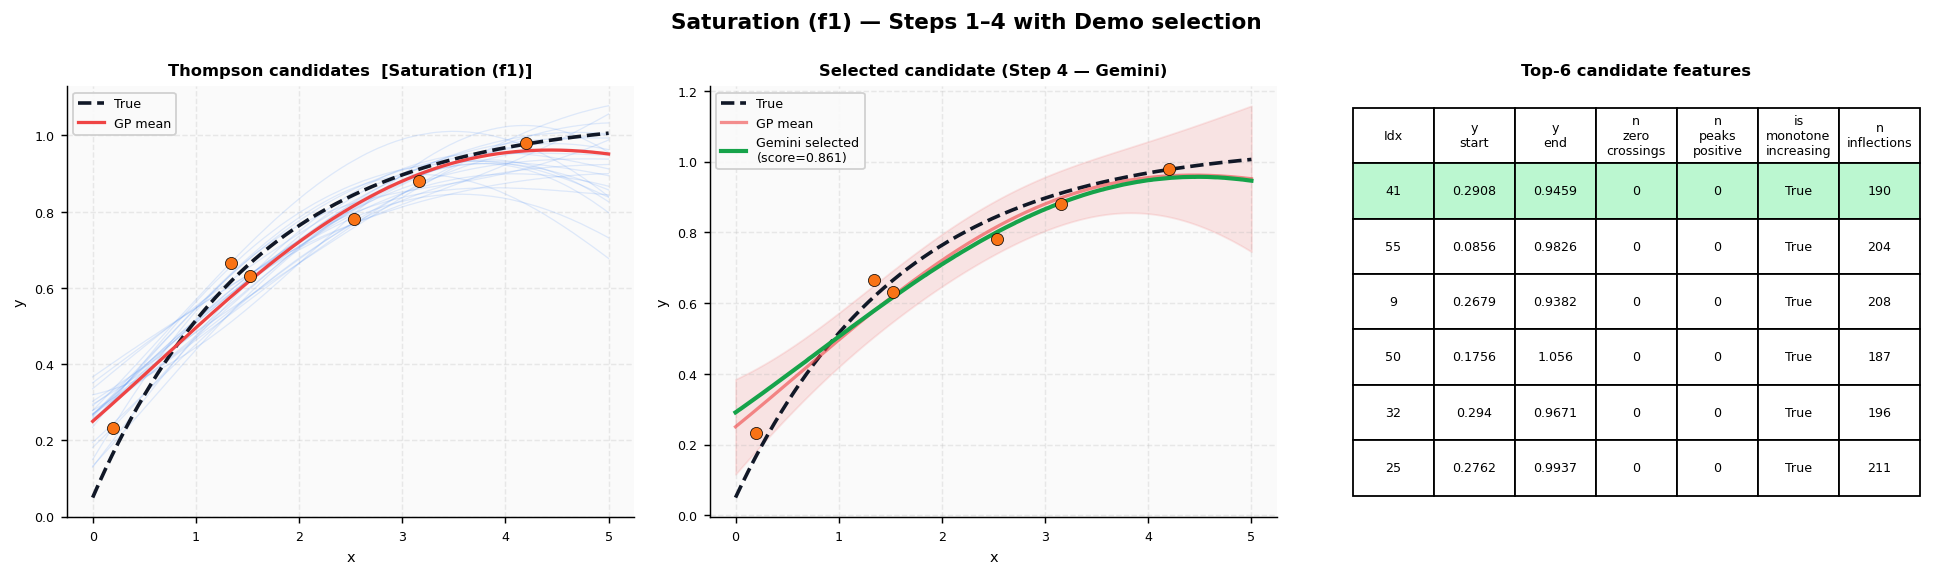


──────────────────────────────────────────────────────────────────────
  f2 — Gemini reasoning:
──────────────────────────────────────────────────────────────────────
  [DEMO MODE — Gemini not configured] Selected candidate 0 based on
  rule-based feature matching for f2.


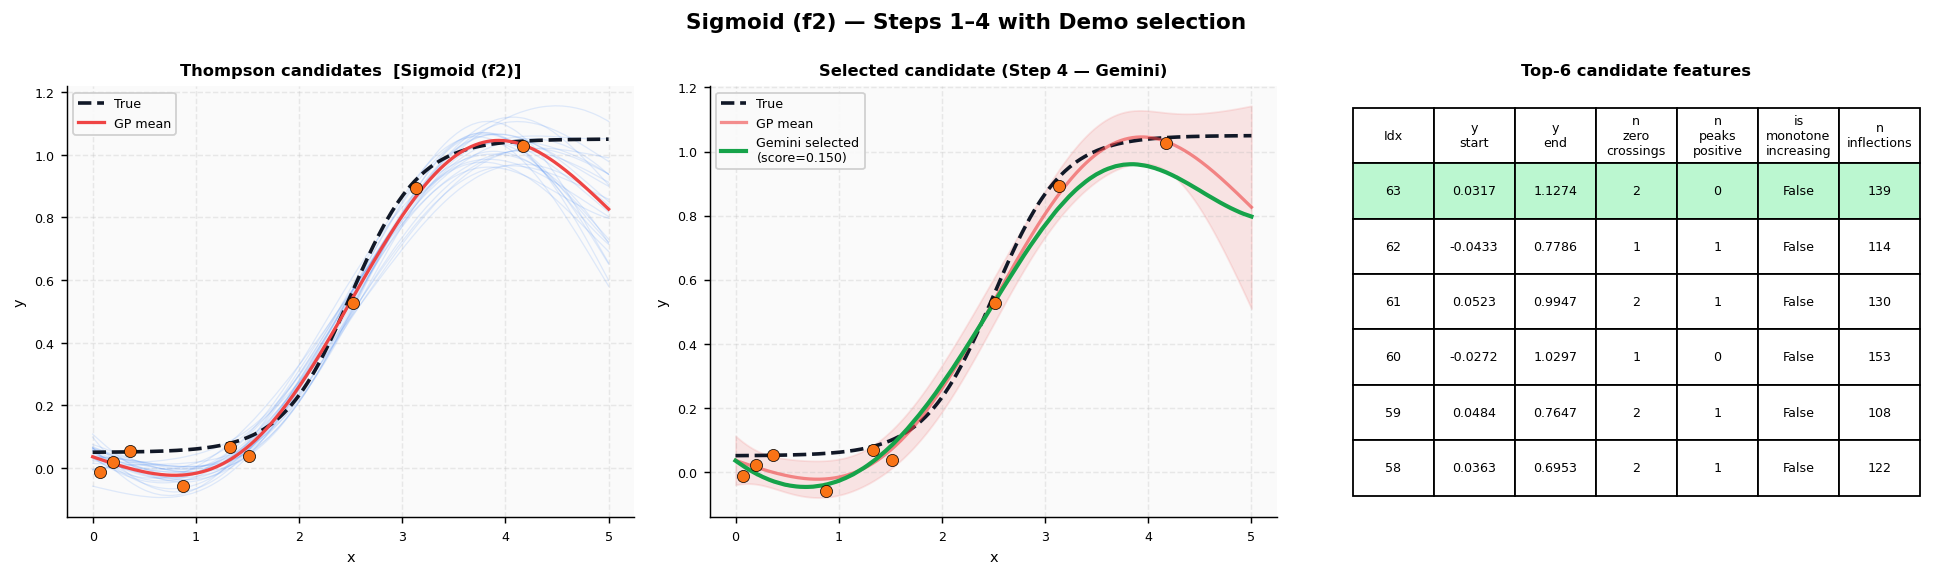


──────────────────────────────────────────────────────────────────────
  f3 — Gemini reasoning:
──────────────────────────────────────────────────────────────────────
  [DEMO MODE — Gemini not configured] Selected candidate 5 based on
  rule-based feature matching for f3.


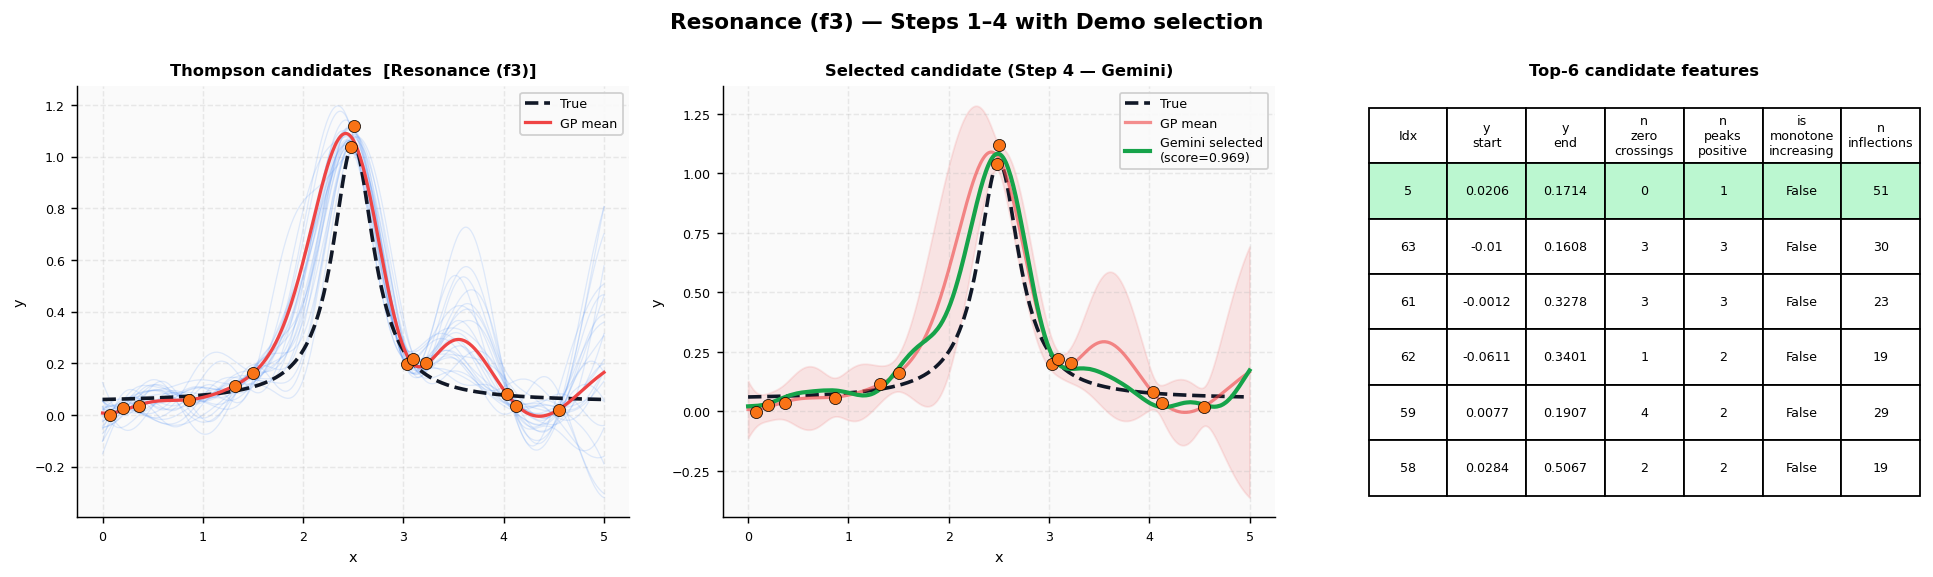


──────────────────────────────────────────────────────────────────────
  f4 — Gemini reasoning:
──────────────────────────────────────────────────────────────────────
  [DEMO MODE — Gemini not configured] Selected candidate 47 based on
  rule-based feature matching for f4.


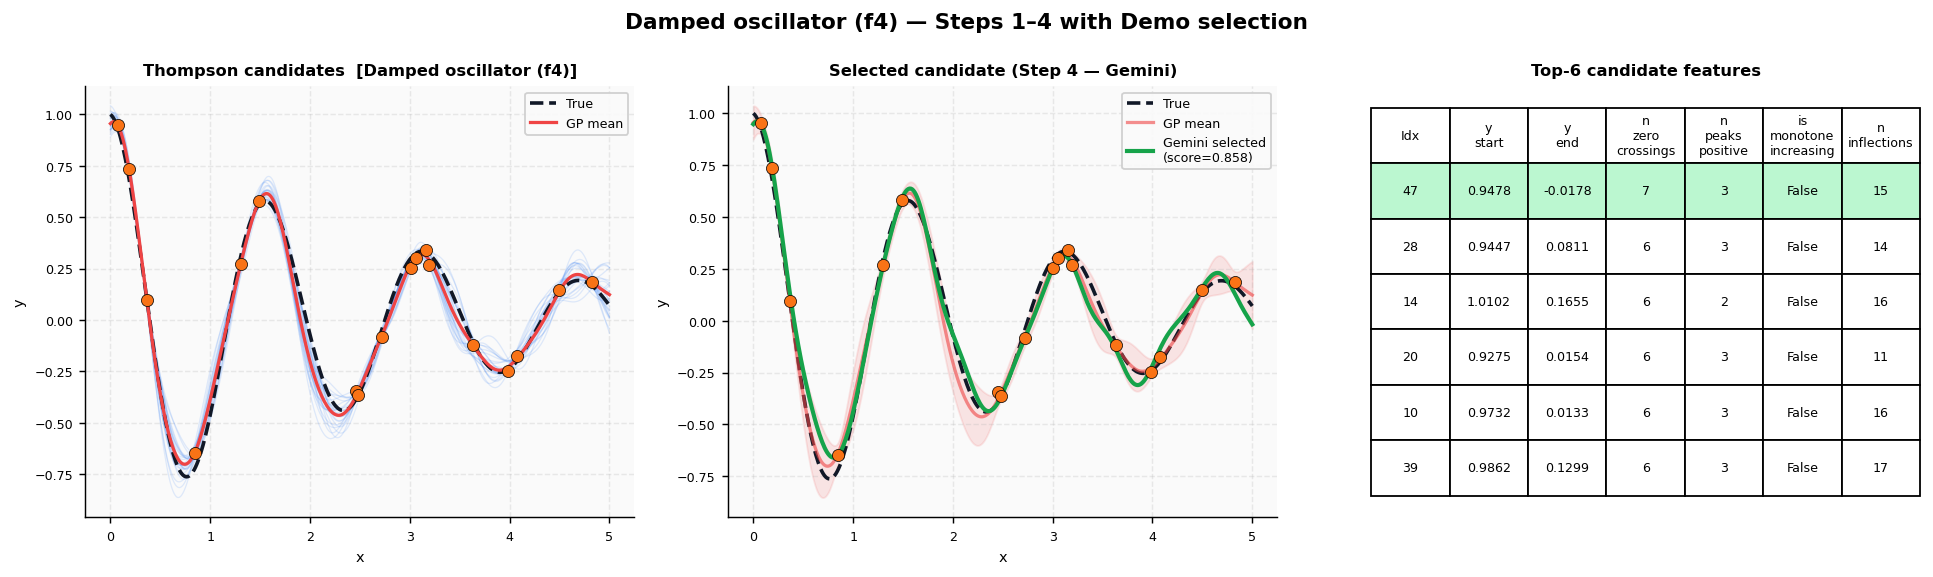

In [38]:
for fname, res in all_results.items():
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4.5))
    fig.suptitle(
        f"{LABELS[fname]} — Steps 1–4 with {'Gemini' if USE_GEMINI else 'Demo'} selection",
        fontsize=12, fontweight="bold"
    )
    plot_result_with_reasoning(res, ax1, ax2, ax3)

    # Print Gemini reasoning below the plot
    print(f"\n{'─'*70}")
    print(f"  {fname} — Gemini reasoning:")
    print(f"{'─'*70}")
    reasoning = res["reasoning"]
    # Wrap text for clean printing
    for line in textwrap.wrap(reasoning, width=68):
        print(f"  {line}")

    plt.tight_layout()
    plt.show()


---
## Section 8 — Full Summary Plot (4 × 2 grid)


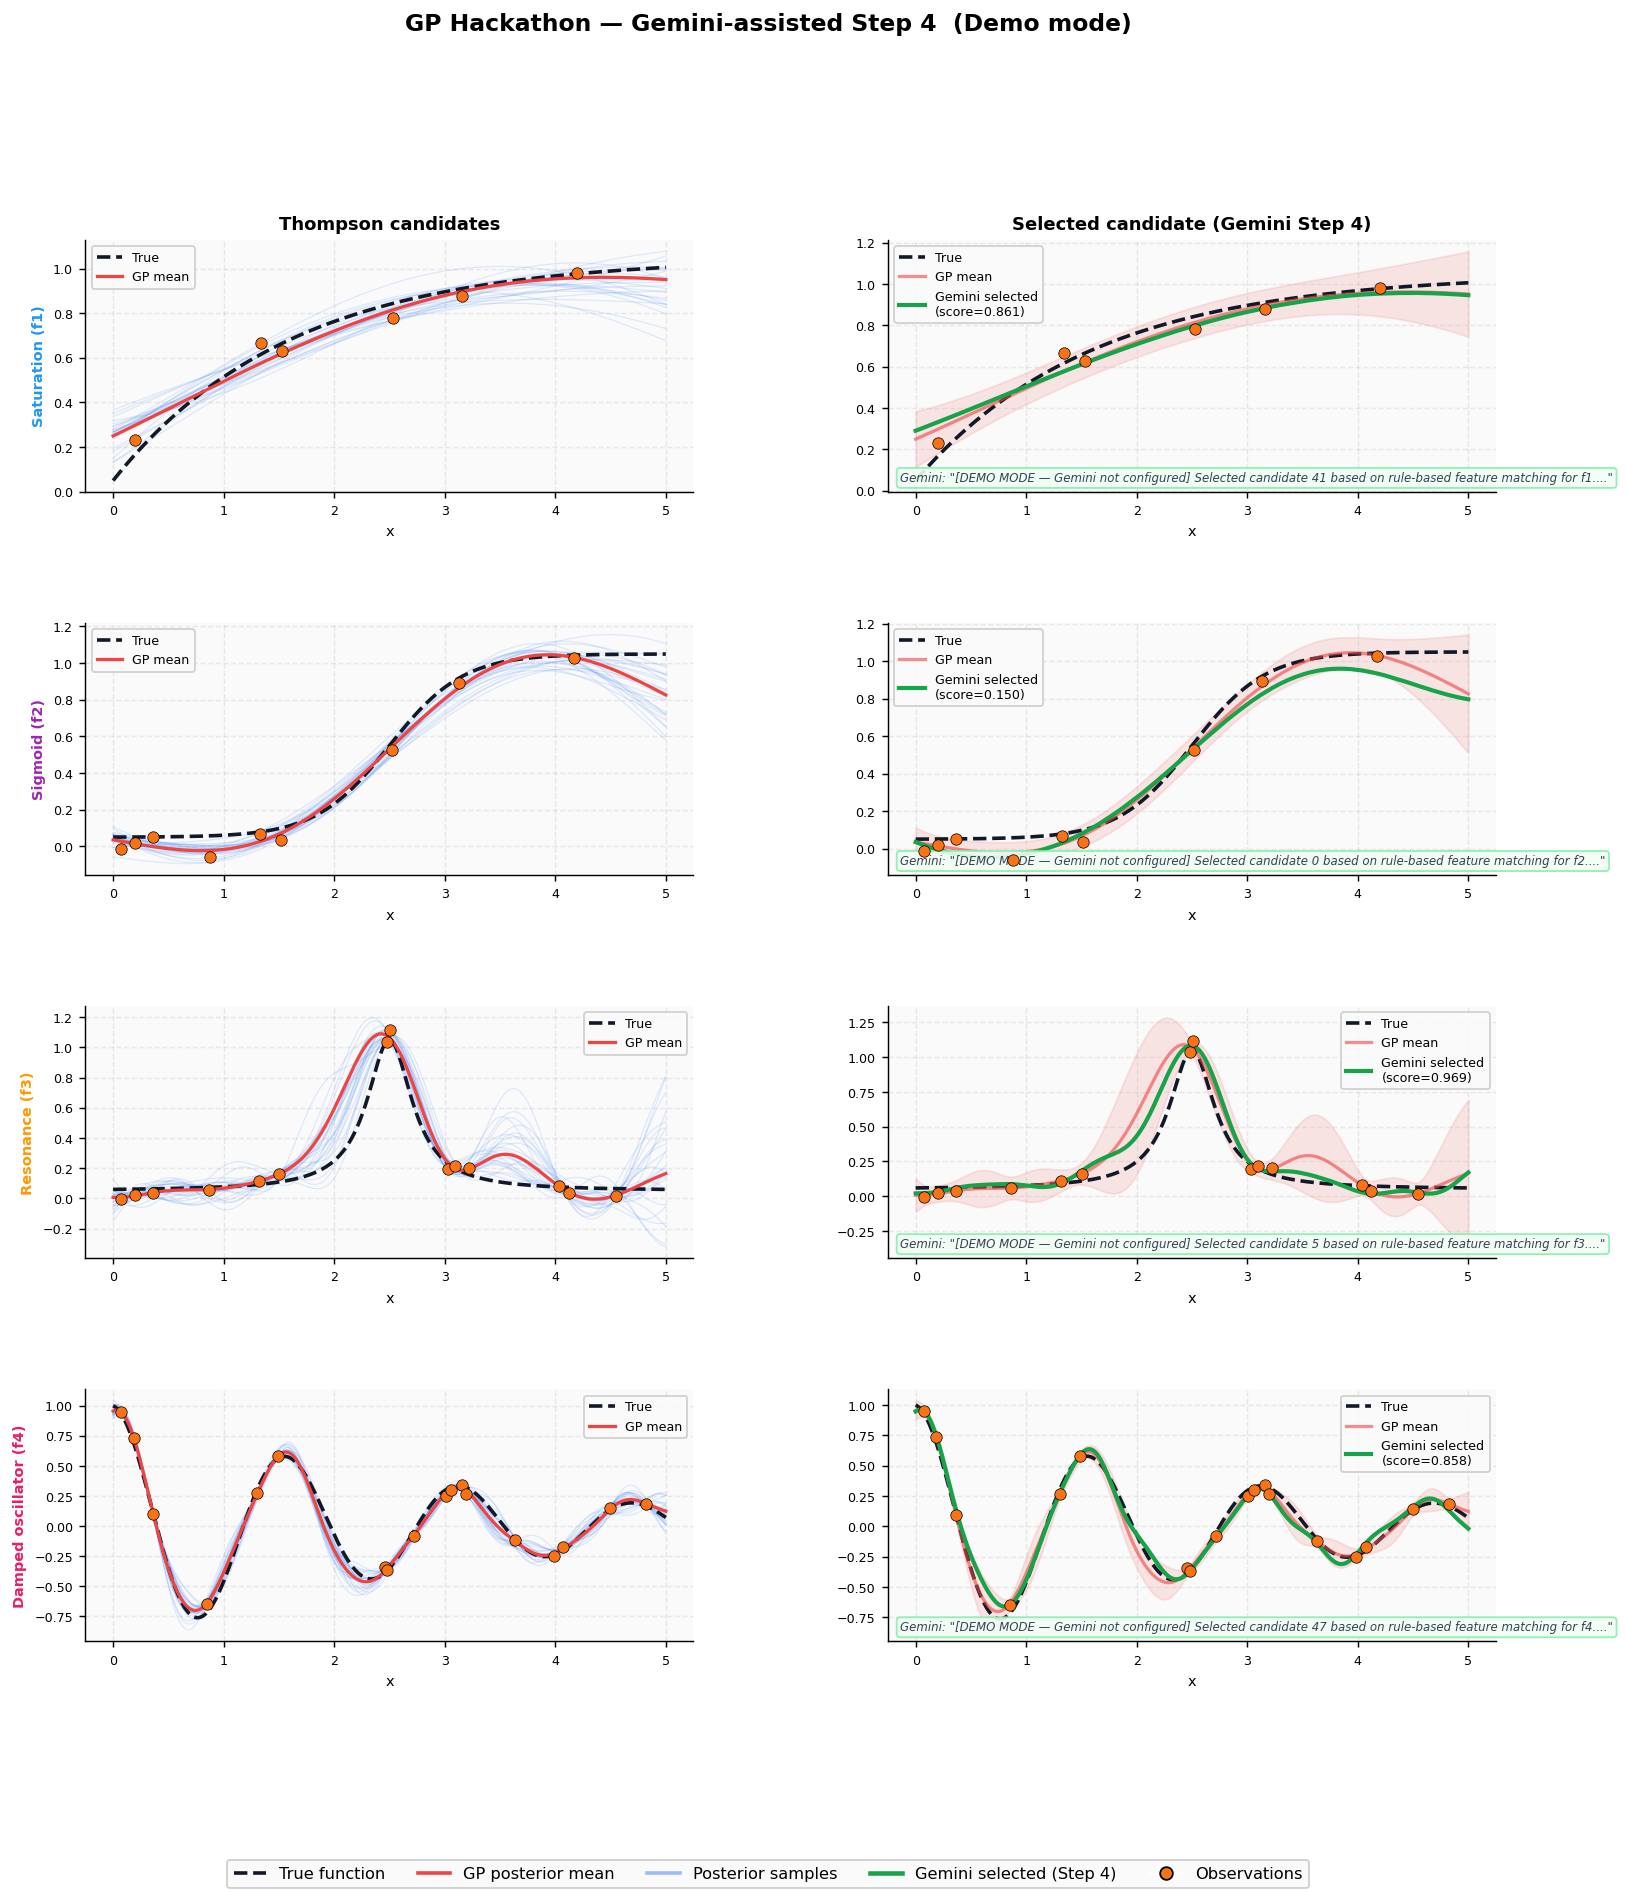

Figure saved: gp_gemini_summary.png


In [39]:
fig = plt.figure(figsize=(14, 14))
fig.patch.set_facecolor("white")
fig.suptitle(
    f"GP Hackathon — Gemini-assisted Step 4  "
    f"({'Live API' if USE_GEMINI else 'Demo mode'})",
    fontsize=13, fontweight="bold", y=1.005
)

gs = gridspec.GridSpec(4, 2, figure=fig, wspace=0.32, hspace=0.52)

for row, (fname, res) in enumerate(all_results.items()):
    f          = res["f"]
    x_obs      = res["x_obs"]; y_obs      = res["y_obs"]
    pred_mean  = res["pred_mean"]; pred_std = res["pred_std"]
    samples    = res["samples"]
    best_idx   = res["best_idx"]; best_score = res["best_score"]
    fc         = FCOLORS[row]

    # ── col 0: all candidates ────────────────────────────────────────────────
    ax0 = fig.add_subplot(gs[row, 0])
    for i in range(min(len(samples), 25)):
        ax0.plot(x_grid, samples[i], color=PALETTE["samples"], alpha=0.15, lw=0.7)
    ax0.plot(x_grid, f(x_grid), color=PALETTE["true"], lw=2, ls="--", label="True")
    ax0.plot(x_grid, pred_mean, color=PALETTE["mean"], lw=1.8, label="GP mean")
    ax0.scatter(x_obs, y_obs, color=PALETTE["observed"], s=40, zorder=5,
                edgecolors="k", linewidths=0.4)
    ax0.set_ylabel(LABELS[fname], fontsize=8, fontweight="bold", color=fc)
    ax0.set_xlabel("x", fontsize=8); ax0.tick_params(labelsize=7)
    ax0.legend(fontsize=7)
    if row == 0:
        ax0.set_title("Thompson candidates", fontsize=10, pad=6)

    # ── col 1: selected + reasoning snippet ──────────────────────────────────
    ax1 = fig.add_subplot(gs[row, 1])
    ax1.fill_between(x_grid, pred_mean - 2*pred_std, pred_mean + 2*pred_std,
                     alpha=0.12, color=PALETTE["band"])
    ax1.plot(x_grid, f(x_grid), color=PALETTE["true"], lw=2, ls="--", label="True")
    ax1.plot(x_grid, pred_mean, color=PALETTE["mean"], lw=1.8, alpha=0.6, label="GP mean")
    ax1.plot(x_grid, samples[best_idx], color=PALETTE["selected"], lw=2.3,
             label=f"Gemini selected\n(score={best_score:.3f})")
    ax1.scatter(x_obs, y_obs, color=PALETTE["observed"], s=40, zorder=5,
                edgecolors="k", linewidths=0.4)
    ax1.set_xlabel("x", fontsize=8); ax1.tick_params(labelsize=7)
    ax1.legend(fontsize=7)
    if row == 0:
        ax1.set_title(
            f"Selected candidate (Gemini Step 4)", fontsize=10, pad=6
        )

    # Reasoning snippet as text annotation
    reasoning_short = res["reasoning"][:130].replace("\n", " ") + "..."
    ax1.text(0.02, 0.03, f"Gemini: \"{reasoning_short}\"",
             transform=ax1.transAxes, fontsize=6.5, color="#374151",
             verticalalignment="bottom", style="italic",
             bbox=dict(boxstyle="round,pad=0.3", facecolor="#f0fdf4",
                       edgecolor="#86efac", alpha=0.9))

# ── shared legend ─────────────────────────────────────────────────────────────
legend_handles = [
    Line2D([0],[0], color=PALETTE["true"],     lw=2, ls="--", label="True function"),
    Line2D([0],[0], color=PALETTE["mean"],     lw=2,          label="GP posterior mean"),
    Line2D([0],[0], color=PALETTE["samples"],  lw=2, alpha=0.5, label="Posterior samples"),
    Line2D([0],[0], color=PALETTE["selected"], lw=2.5,        label="Gemini selected (Step 4)"),
    Line2D([0],[0], marker="o", color="w", markerfacecolor=PALETTE["observed"],
           markersize=7, markeredgecolor="k", label="Observations"),
]
fig.legend(handles=legend_handles, loc="lower center", ncol=5,
           fontsize=9, bbox_to_anchor=(0.5, -0.03), framealpha=0.95)

plt.savefig("gp_gemini_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: gp_gemini_summary.png")


In [40]:
# ── Quantitative comparison: GP mean vs Gemini-selected candidate ────────────
print(f"\n{'Function':<26} {'GP mean RMSE':>14} {'Gemini RMSE':>13} {'Improvement':>13}")
print("─" * 68)

for fname, res in all_results.items():
    y_true    = res["f"](x_grid)
    rmse_mean = float(np.sqrt(np.mean((res["pred_mean"] - y_true)**2)))
    rmse_sel  = float(np.sqrt(np.mean((res["samples"][res["best_idx"]] - y_true)**2)))
    delta     = (rmse_mean - rmse_sel) / rmse_mean * 100
    arrow     = "↑ better" if delta > 0 else "↓ worse"
    print(f"  {LABELS[fname]:<24} {rmse_mean:>10.4f}    {rmse_sel:>10.4f}   "
          f"{delta:>+7.1f}%  {arrow}")



Function                     GP mean RMSE   Gemini RMSE   Improvement
────────────────────────────────────────────────────────────────────
  Saturation (f1)              0.0497        0.0626     -26.1%  ↓ worse
  Sigmoid (f2)                 0.0648        0.1004     -55.1%  ↓ worse
  Resonance (f3)               0.1415        0.0932     +34.1%  ↑ better
  Damped oscillator (f4)       0.0467        0.0597     -27.6%  ↓ worse


---
## Section 10 — Interactive: Ask Gemini About Any Candidate

You can query Gemini directly to ask it to explain any candidate or explore
the reasoning for a specific index.

In [41]:
# ── Interactive query — modify as you like ───────────────────────────────────
TARGET_FUNCTION = "f4"          # which function to explore
CANDIDATE_INDEX = 0             # which candidate index to ask about

res      = all_results[TARGET_FUNCTION]
features = res["features_list"][CANDIDATE_INDEX]
fname    = TARGET_FUNCTION

if USE_GEMINI:
    query = f"""
    {PHYSICS_CONTEXT[fname].strip()}

    A specific candidate function (index {CANDIDATE_INDEX}) has these features:
    {json.dumps(features, indent=2)}

    Please explain:
    1. Does this candidate match the expected physical behaviour?
    2. What specific features make it a good or poor candidate?
    3. Give it a score from 0.0 to 1.0 with justification.
    """
    response = model_gemini.generate_content(query)
    print(f"Gemini's assessment of candidate {CANDIDATE_INDEX} for {fname}:")
    print("─" * 60)
    print(response.text)
else:
    print(f"[DEMO MODE] Feature summary for candidate {CANDIDATE_INDEX} ({fname}):")
    print(json.dumps(features, indent=2))
    print("\nSet GEMINI_API_KEY to get Gemini's qualitative reasoning.")


[DEMO MODE] Feature summary for candidate 0 (f4):
{
  "y_start": 0.9437,
  "y_end": 0.0497,
  "y_min": -0.6708,
  "y_max": 0.9495,
  "y_range": 1.6203,
  "frac_increasing": 0.525,
  "frac_decreasing": 0.4725,
  "is_monotone_increasing": false,
  "frac_concave_up": 0.5025,
  "frac_concave_down": 0.4975,
  "n_inflections": 13,
  "n_peaks_positive": 4,
  "peak_x_positions": [
    1.554,
    3.133,
    3.784
  ],
  "n_zero_crossings": 6,
  "tail_mean": 0.0305,
  "tail_std": 0.154,
  "tail_is_flat": false,
  "saturation_delta": 0.1295
}

Set GEMINI_API_KEY to get Gemini's qualitative reasoning.


---
## Section 11 — Notes on Prompt Engineering

### What works well
- **Physics context first**: telling Gemini the physical domain (RC charging, etc.) dramatically improves scoring quality
- **Feature JSON, not raw arrays**: Gemini reasons better over named statistics than 400 raw floats
- **Structured output request**: asking for JSON with a fixed schema avoids hallucinated formats
- **Explicit rejection criteria**: listing what should NOT be present (oscillations, negative values) is as important as positive criteria

### What to try next
- **Chain-of-thought prompting**: ask Gemini to reason step by step before giving the final JSON
- **Few-shot examples**: include one ideal candidate's features as a reference in the prompt
- **Multi-turn dialogue**: ask Gemini to refine its choice after seeing the top-3 plotted
- **Gemini Pro / 1.5**: upgrade for longer context windows (can include more candidates)

### Limitations
- Gemini cannot see the actual curve — only the extracted features
- Feature extraction quality limits selection quality
- API rate limits apply (free tier: ~15 requests/minute)
- For production use, cache responses to avoid repeated API calls
